In [ ]:
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 4.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
import torch.nn as nn
import supervision as sv
import os


In [ ]:
def load_best_model(model_path, device='cpu'):

    model = deeplabv3_mobilenet_v3_large(pretrained=False)
    model.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)
    model = model.to(device)
    state_dict = torch.load(model_path, map_location=torch.device(device))
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

In [ ]:
def preprocess_image(image_path, input_size=(224, 224)):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(input_size),
        transforms.ToTensor()
    ])
    image_tensor = transform(image).unsqueeze(0)
    return image_tensor

In [ ]:
def run_inference(model, image_tensor, device='cpu'):
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        output = model(image_tensor)
        predictions = output["out"]
        if predictions.shape[1] == 1:
            mask = (torch.sigmoid(predictions) > 0.5).float()
        else:
            mask = torch.argmax(predictions, dim=1, keepdim=True).float()
        return mask.squeeze().cpu().numpy()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import supervision as sv
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import supervision as sv


def plot_segmentation_with_supervision(image_path, mask):

    image_rgb = np.array(Image.open(image_path).convert("RGB"))

    if mask.shape[:2] != image_rgb.shape[:2]:
        mask = cv2.resize(mask.astype(np.uint8), (image_rgb.shape[1], image_rgb.shape[0]),
                          interpolation=cv2.INTER_NEAREST)

    bool_mask = mask.astype(bool)
    ys, xs = np.where(bool_mask)
    if len(ys) == 0 or len(xs) == 0:
        print("The mask is empty. No object detected.")
        return
    x_min, y_min = xs.min(), ys.min()
    x_max, y_max = xs.max(), ys.max()

    bbox = [x_min, y_min, x_max - x_min, y_max - y_min]

    sam_result = [{
        'segmentation': bool_mask,
        'area': int(np.sum(mask)),
        'bbox': bbox
    }]

    detections = sv.Detections.from_sam(sam_result=sam_result)
    mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
    annotated_image = mask_annotator.annotate(scene=image_rgb.copy(), detections=detections)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(image_rgb)
    axs[0].set_title("Input Image")
    axs[0].axis("off")
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Generated Mask")
    axs[1].axis("off")
    axs[2].imshow(annotated_image)
    axs[2].set_title("Overlayed Image")
    axs[2].axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
test_image_path = '/content/drive/MyDrive/Projects/PR/Ground_segmentation/dataset/split_dataset/test/images'
test_iamges = os.listdir(test_image_path)
print(len(test_iamges))

155


In [ ]:

path_model = '/content/drive/MyDrive/Projects/PR/Ground_segmentation/MODELS/fine_tuned_segmentation_models/_MP_finetuned_model_I_.pth'
print(os.path.exists(path_model))


True


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = load_best_model(path_model, device=device)
print("modle loading done")

modle loading done


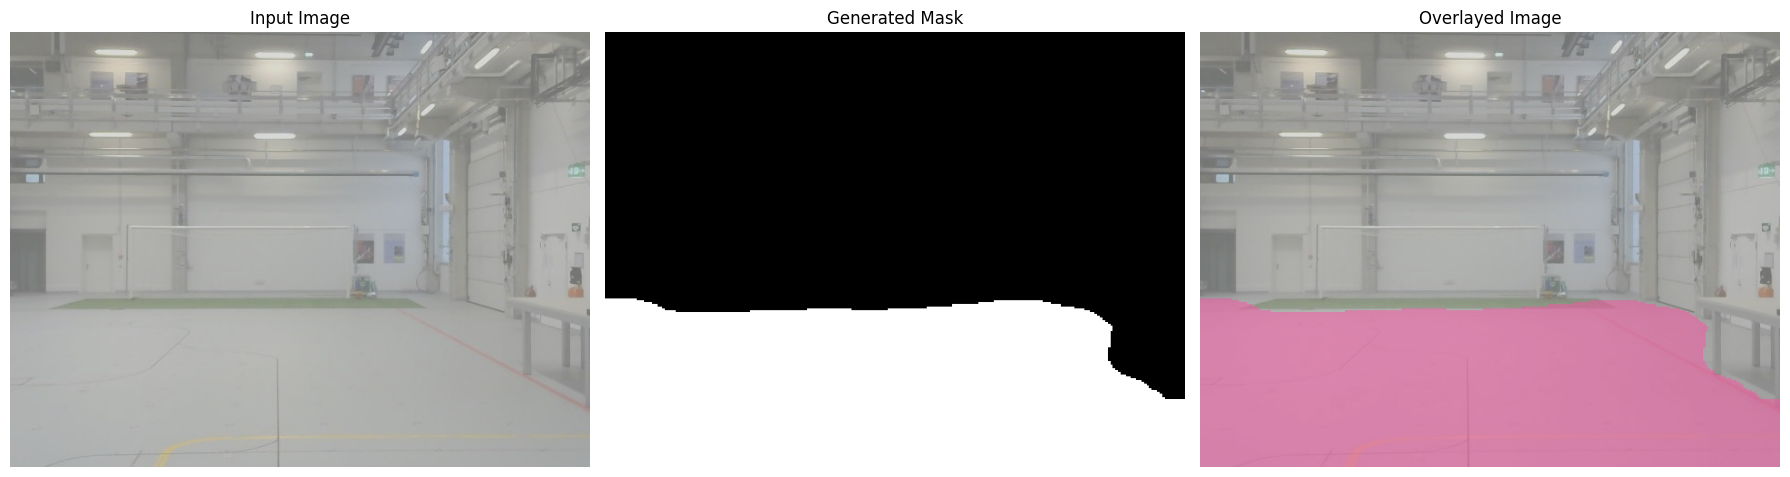

In [ ]:
for i in range(len(test_iamges)):
  full_path = os.path.join(test_image_path, test_iamges[i])
  image_tensor = preprocess_image(full_path)
  mask = run_inference(model, image_tensor, device=device)
  plot_segmentation_with_supervision(full_path, mask)


In [ ]:
# COMPARING BOTH THE MODELS